In [31]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [33]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [34]:
from utils.cart import make_wcs, to_cart

In [35]:
cmap = 'RdBu_r'

In [36]:
! nvidia-smi

Mon Apr 11 09:35:37 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   34C    P0    25W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   

## Templates

In [37]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [38]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# ROI mask
mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0


## Exposure of real data

In [39]:
from astropy.io import fits

In [40]:
exp_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/exposure_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
upsample_factor_data = int(pixel_size_target / pixel_size_data)
extent = 25
i_e = 40

In [41]:
exp = exp_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = exp.shape[0] // upsample_factor_data
exp_downsampled = exp.reshape(-1, upsample_factor_data, b, upsample_factor_data).sum((-1, -3))
exp_downsampled_norm = exp_downsampled / np.mean(exp_downsampled)

## Sims

In [42]:
from models.scd import dnds

In [43]:
# Templates
temps_ps = np.array([temp_gce_cart, temp_dsk_cart])
temps_poiss = np.array([temp_gce_cart, temp_iso_cart, temp_bub_cart, temp_psc_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])

# Make upsampled versions of PS templates

temps_ps_upsampled = []

mesh_dim = np.linspace(0, n_pixels, n_pixels * upsample_factor)

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)
    
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), exp_downsampled_norm)
exp_upsampled_norm = interp(mesh_dim, mesh_dim)

In [45]:
def simulate(n_sim=1000):
    
    # Priors

    prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
                [3., 20.0, 1.99, 1.99, 40.0, 4.99, 3., 20.0, 1.99, 1.99, 40.0, 4.99]]

    prior_poiss = [[0.001, 0.001, 0.001, 0.001, 16.0, 6.0], 
                   [3., 1.5, 1., 1., 21.0, 7.0]]

    # Generate parameters from prior
    thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

    s_ary = np.logspace(-1, 2, 1000)
    logs_ary = np.log10(s_ary)
    dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

    s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
    ds_ary = np.diff(s_for_ds_ary)

    signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
    flux_fraction = np.zeros((n_sim, len(temps_ps) + len(temps_poiss)))
    dnds_ary = []

    for idx_theta, theta in enumerate(tqdm(thetas)):

        idx_theta_ps = len(temps_poiss)

        for idx, temp_ps in enumerate(temps_ps):

            dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
            s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
            dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
            dnds_ary.append(dnds_ary_temp)
            idx_theta_ps += 6

            n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

            # Sample, accounting for dS factor for log-space sampling
            sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

            dist = temps_ps_upsampled[idx]
            dist /= dist.sum() 
            pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
            inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)), p=dist.reshape(-1),size=n_ps,replace=True)
            selections = pairs.reshape(-1, 2)[inds]
            hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]

            sigma_mu = gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.)
            sigma_mu *= exp_upsampled_norm
            signal = np.random.poisson(sigma_mu)

            b = signal.shape[0] // upsample_factor
            signal_reshaped = signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

            signal_ensemble[idx_theta, :, :] += signal_reshaped

            flux_fraction[idx_theta, idx] = signal_reshaped.mean()

        flux_fraction[idx_theta, 2:] = (temps_poiss.T * theta[:len(temps_poiss)]).mean((0,1))
        signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], temps_poiss))

    flux_fraction = (flux_fraction.T / flux_fraction.sum(1)).T
    
    return signal_ensemble, flux_fraction

In [ ]:
signal_ensemble, flux_fraction = simulate(100000)

  0%|          | 0/100000 [00:00<?, ?it/s]

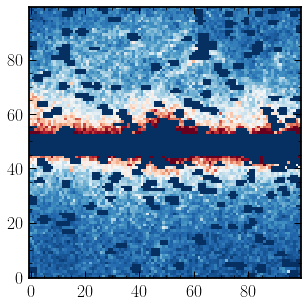

In [30]:
plt.imshow(signal_ensemble[2] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

In [119]:
np.savez("../data/samples/data_uniform.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

In [ ]:
signal_ensemble, flux_fraction = simulate(1000)

In [43]:
np.savez("../data/samples/data_uniform_test.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)